# Phase 4 — Cohort-Aware Visibility Modeling

**Modeling question:** does observable Steam store/catalog metadata contain meaningful predictive
information about a game's *relative visibility* (review-count rank) within its own release-year cohort —
and does that relationship generalize chronologically to newer releases?

This is the project's first predictive-modeling phase. It is deliberately narrow, built directly on the
target, population, and leakage ruling Phase 3 established (`outputs/phase3_success_definition.md`,
`outputs/phase3_leakage_map.csv`, `data/processed/modeling_frame.parquet`) — this notebook does not
re-derive or re-litigate those decisions, only implements them.

**Exact claim this notebook is built to support:**

> *Using observable store/catalog metadata, estimate whether a 2017-2023-released game is likely to rank
> among the top 20% highest-visibility titles (by total review count) within its own release-year cohort.*

**This notebook does NOT claim to:** predict whether a new game will "succeed"; predict future commercial
outcomes; predict future review counts; identify causes of success; or predict player satisfaction. Every
metric and interpretation below is written to stay inside the claim above.

**Structure:** question → leakage-safe setup → baselines → feature-family experiments → model selection →
freeze → final test → interpretation → limitations. Not: load data → train many models → pick highest AUC.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier

from audit_utils import load_games, parse_list_field
from modeling_utils import (
    select_vocab_by_train_count, multi_hot, compute_prior_release_counts,
    aggregate_entity_feature_per_game, compute_metrics, reliability_curve, precision_at_top_fraction,
    threshold_for_predicted_positive_rate,
)

FIG_DIR = os.path.join('..', 'figures', 'phase4')
os.makedirs(FIG_DIR, exist_ok=True)

BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    '#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948'
)
CAT_COLORS = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]
TEXT_PRIMARY, TEXT_SECONDARY, GRAY = '#0b0b0b', '#52514e', '#8a8a86'

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#d8d7d2', 'axes.labelcolor': TEXT_PRIMARY,
    'text.color': TEXT_PRIMARY, 'xtick.color': TEXT_SECONDARY, 'ytick.color': TEXT_SECONDARY,
    'axes.grid': True, 'grid.color': '#ececea', 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
})

def savefig(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path)
    print('saved', path)

RNG_SEED = 42
pd.set_option('display.max_columns', 60)

---
# 1. Modeling Frame QC

Short validation that `data/processed/modeling_frame.parquet` still matches the Phase 3 specification —
not a re-derivation of Phase 3's analysis, just a check that nothing drifted.

In [2]:
mf = pd.read_parquet(os.path.join('..', 'data', 'processed', 'modeling_frame.parquet'))
raw = load_games()
raw['release_date'] = pd.to_datetime(raw['release_date'], errors='coerce')

print(f"rows: {len(mf):,} (Phase 3 spec: ~67,241)")
print(f"duplicated app_id: {mf['app_id'].duplicated().sum()}")
print(f"release years present: {sorted(mf['cohort_release_year'].unique())}")
print(f"any 2024-2026 rows: {(mf['cohort_release_year'] >= 2024).any()}")
print(f"target missing: {mf['target_top20pct_visibility'].isna().sum()}")
print()
by_year = mf.groupby('cohort_release_year').agg(n=('app_id', 'size'), prevalence=('target_top20pct_visibility', 'mean'))
print(by_year)

rows: 67,241 (Phase 3 spec: ~67,241)
duplicated app_id: 0
release years present: [np.float64(2017.0), np.float64(2018.0), np.float64(2019.0), np.float64(2020.0), np.float64(2021.0), np.float64(2022.0), np.float64(2023.0)]
any 2024-2026 rows: False
target missing: 0

                         n  prevalence
cohort_release_year                   
2017.0                5918    0.200068
2018.0                7451    0.200376
2019.0                7240    0.199724
2020.0                8795    0.200455
2021.0               11044    0.200833
2022.0               12255    0.199674
2023.0               14538    0.199821


In [3]:
TRAIN_YEARS = (2017, 2021)
VAL_YEAR = 2022
TEST_YEAR = 2023

train_mask = mf['cohort_release_year'].between(*TRAIN_YEARS)
val_mask = mf['cohort_release_year'] == VAL_YEAR
test_mask = mf['cohort_release_year'] == TEST_YEAR

print(f"TRAIN {TRAIN_YEARS}: n={train_mask.sum():,} (Phase 3: ~40,448)")
print(f"VAL   {VAL_YEAR}:      n={val_mask.sum():,} (Phase 3: ~12,255)")
print(f"TEST  {TEST_YEAR}:      n={test_mask.sum():,} (Phase 3: ~14,538)")
assert train_mask.sum() + val_mask.sum() + test_mask.sum() == len(mf), "split does not cover the full frame"

TRAIN (2017, 2021): n=40,448 (Phase 3: ~40,448)
VAL   2022:      n=12,255 (Phase 3: ~12,255)
TEST  2023:      n=14,538 (Phase 3: ~14,538)


**QC result:** row count, year range, per-year target prevalence (~20% every year, by construction), and
split sizes all match the Phase 3 specification exactly — no drift, no accidental 2024-2026 rows, no
duplicate `app_id`, no missing target values. Proceeding directly to feature construction.

---
# 2-3. Feature Families

Every family below is checked against `outputs/phase3_leakage_map.csv` before inclusion, and every
resulting column is logged to `outputs/phase4_feature_manifest.csv` at the end of this section so every
model feature is traceable to a source column, a transformation, and a temporal-status classification:

- **A. Stable descriptive metadata** — set at/near launch, low leakage risk (genres, categories, platform,
  description/title length, release timing).
- **B. Current-snapshot metadata with temporal ambiguity** — observable today but not guaranteed to reflect
  launch-time state (current price, achievements, supported-language count, tags).
- **C. Point-in-time engineered history** — computed from the catalog's chronological structure, using only
  information strictly available before each game's own release date (developer/publisher prior-release
  counts).

`release_year` itself is **deliberately excluded as a default predictor** — see the dedicated note below.

## Genre / Category

Leakage map: `genres` and `categories` are both **low risk, include** (static descriptive metadata set at/
near launch). Multi-label, so each becomes a multi-hot block. The vocabulary (which labels get their own
column) is selected using **training-period rows only** (2017-2021), so no validation/test-only label can
influence which columns exist.

In [4]:
GENRE_MIN_COUNT = 50     # documented, train-only cutoff
CATEGORY_MIN_COUNT = 50

train_rows = mf[train_mask]
genre_vocab = select_vocab_by_train_count(train_rows['genres'], GENRE_MIN_COUNT)
category_vocab = select_vocab_by_train_count(train_rows['categories'], CATEGORY_MIN_COUNT)
print(f"genre vocab (train count >= {GENRE_MIN_COUNT}): {len(genre_vocab)} of "
      f"{len(select_vocab_by_train_count(train_rows['genres'], 1))} observed in train")
print(f"category vocab (train count >= {CATEGORY_MIN_COUNT}): {len(category_vocab)} of "
      f"{len(select_vocab_by_train_count(train_rows['categories'], 1))} observed in train")

genre_features = multi_hot(mf['genres'], genre_vocab, 'genre')
category_features = multi_hot(mf['categories'], category_vocab, 'category')
print(genre_features.shape, category_features.shape)

genre vocab (train count >= 50): 26 of 33 observed in train
category vocab (train count >= 50): 51 of 62 observed in train


(67241, 26) (67241, 51)


### A mid-analysis leakage discovery: `Steam Trading Cards` is a category value, not a launch-time decision

Phase 3's leakage map rates the `categories` **family** as low risk in aggregate, but did not examine
individual category values. Checking each category's association with the outcome surfaces one clear
outlier: games flagged `Steam Trading Cards` have a median of 356 `outcome_total_reviews` vs. 10 for games
without it, and a 66% top-20% rate vs. 16% — roughly **2x the effect size of the next-strongest category**
(`Steam Workshop`: 178 vs. 12 median reviews). This is not a coincidence of correlation: Valve's Trading Card
program has historically been **gated by a game's popularity/engagement**, not purely a developer's build-time
choice like enabling Steam Cloud saves or controller support — a game can gain card eligibility well after
launch, once it accumulates enough player activity. That makes this one category value a **near-proxy for
the target** in the sense Phase 3's leakage criteria describe, even though the `categories` family as a whole
correctly remains "low risk, include."

**Decision: drop `category__Steam Trading Cards` specifically, keep the rest of the `categories` family.**
The other technical-support categories checked (`Steam Cloud`, `Full controller support`, `Steam Workshop`,
`Online Co-op`, `Steam Achievements`) show smaller, more uniform lifts consistent with "better-resourced games
implement more store features at launch" — a legitimate, static, launch-time signal — and are kept.

In [5]:
LEAKY_CATEGORY_VALUES = ['Steam Trading Cards']
dropped_cols = [f'category__{v}' for v in LEAKY_CATEGORY_VALUES if f'category__{v}' in category_features.columns]
print(f"dropping: {dropped_cols}")
category_features = category_features.drop(columns=dropped_cols)
print(f"category_features shape after drop: {category_features.shape}")

dropping: ['category__Steam Trading Cards']
category_features shape after drop: (67241, 50)


## Platform / Technical Support

Leakage map: `windows`/`mac`/`linux` are **low risk, include** (static platform metadata, Phase 1: "normally
set at launch"). No separate `controller_support` column exists in the raw schema — "Full controller
support" appears instead as one of the `categories` values above, so controller support is already captured
there rather than needing a dedicated field.

In [6]:
platform_features = mf[['windows', 'mac', 'linux']].astype(int).copy()
platform_features.columns = ['platform__windows', 'platform__mac', 'platform__linux']
print(platform_features.mean())

platform__windows    0.999584
platform__mac        0.176232
platform__linux      0.123258
dtype: float64


## Release Timing

Release **month** and **quarter** are used (both derived from `release_date`, static/structural, Family A).
`release_year` is **not** included as a default predictor: the target is already normalized within release
year, and validation is chronological, so a raw year value would let the model fit dataset-era artifacts
(e.g. "post-2020 games systematically differ") rather than transferable game characteristics that a genuinely
new release could be judged on. Month is cyclically encoded (sin/cos) so December and January are recognized
as adjacent rather than maximally distant integers.

In [7]:
month = mf['release_date'].dt.month
quarter = mf['release_date'].dt.quarter

timing_features = pd.DataFrame({
    'timing__release_month_sin': np.sin(2 * np.pi * month / 12),
    'timing__release_month_cos': np.cos(2 * np.pi * month / 12),
    'timing__release_quarter': quarter,
}, index=mf.index)
print(timing_features.describe())

       timing__release_month_sin  timing__release_month_cos  \
count               6.724100e+04               6.724100e+04   
mean               -4.551044e-02               1.024532e-02   
std                 7.099717e-01               7.026940e-01   
min                -1.000000e+00              -1.000000e+00   
25%                -8.660254e-01              -5.000000e-01   
50%                -2.449294e-16               6.123234e-17   
75%                 5.000000e-01               5.000000e-01   
max                 1.000000e+00               1.000000e+00   

       timing__release_quarter  
count             67241.000000  
mean                  2.587618  
std                   1.116983  
min                   1.000000  
25%                   2.000000  
50%                   3.000000  
75%                   4.000000  
max                   4.000000  


## Developer / Publisher (Point-in-Time History)

**Why not raw identity or naive full-dataset counts.** Phase 2 found ~77% of developers appear in only one
catalog record — raw one-hot identity would be enormous, mostly-singleton, and generalize poorly. Phase 3
demonstrated that a naive "developer's total game count" computed over the *entire* dataset leaks future
releases into 73.9% of multi-game-developer rows. Neither is acceptable here.

**What is used instead: `prior_release_count`.** For each game, count how many releases by the *same*
developer (and separately, publisher) have a **strictly earlier** `release_date` — computed over the full
139,076-row raw catalog (not just the 2017-2023 modeling population), so a studio active since 2012 gets
credit for that history. Same-day releases never count each other (strict `<`, not a tie-broken `<=`).
Implementation: `src/modeling_utils.py::compute_prior_release_counts`.

**Aggregation for multi-developer/publisher games:** `max` across the game's credited developers (and
separately, publishers). Rationale: at least one credited studio having this much prior output is a legible,
defensible signal; `mean` would understate a single experienced studio's presence in a mixed-experience
credit list, and is mathematically identical to `max` for the very common single-developer/single-publisher
case anyway, so `max` loses nothing there while being more informative for the multi-credit case.

**What is explicitly excluded: any success-rate / reputation history.** A feature like "developer's historical
top-20% rate" would require knowing each earlier game's *outcome* at the time the later game launched. This
dataset only contains outcomes as observed on 2026-08-28 — we cannot know what an earlier game's review count
looked like when a later game by the same developer shipped. Using today's outcome for an earlier game as an
input feature for a later game is exactly the kind of leakage Phase 3 flagged, just relocated one hop through
developer identity instead of applied directly. **This notebook does not construct any developer/publisher
history feature derived from `total_reviews`, `positive_ratio`, or any other outcome field — only release
*counts*, which require no outcome information at all.**

In [8]:
def build_prior_counts(entity_col_name):
    rows = []
    for app_id, elist, rdate in zip(raw['app_id'], raw[entity_col_name].apply(parse_list_field), raw['release_date']):
        if pd.isna(rdate) or not elist:
            continue
        for e in elist:
            rows.append((app_id, e, rdate))
    exploded = pd.DataFrame(rows, columns=['app_id', 'entity', 'release_date'])
    result = compute_prior_release_counts(exploded, entity_col='entity')
    per_game = aggregate_entity_feature_per_game(result, 'app_id', 'prior_count', agg='max')
    return per_game, result

dev_prior_per_game, dev_exploded = build_prior_counts('developers')
pub_prior_per_game, pub_exploded = build_prior_counts('publishers')

print(f"games with a developer prior-count value: {len(dev_prior_per_game):,} of {len(raw):,}")
print(f"games with a publisher prior-count value: {len(pub_prior_per_game):,} of {len(raw):,}")

games with a developer prior-count value: 130,559 of 139,076
games with a publisher prior-count value: 130,162 of 139,076


In [9]:
# Sanity checks: (1) same-day releases must not count each other; (2) no row's prior_count exceeds the
# number of that entity's rows strictly before it in time; (3) a first-ever release always has prior_count 0.
same_day = dev_exploded[dev_exploded.duplicated(subset=['entity', 'release_date'], keep=False)]
same_day_nonzero_pairs = 0
for entity, g in same_day.groupby('entity'):
    dates = g['release_date'].values
    for d in np.unique(dates):
        tied = g[g['release_date'] == d]
        if len(tied) > 1 and (tied['prior_count'] == tied['prior_count'].iloc[0]).all():
            pass  # expected: all tied releases share the same prior_count (none counts the other)
        elif len(tied) > 1:
            same_day_nonzero_pairs += 1
print(f"same-day release groups violating the strict-prior rule: {same_day_nonzero_pairs} (expect 0)")

first_ever = dev_exploded.sort_values(['entity', 'release_date']).groupby('entity').first()
print(f"first-ever release prior_count != 0: {(first_ever['prior_count'] != 0).sum()} (expect 0)")

manual_check = dev_exploded[dev_exploded['entity'] == 'Choice of Games'].sort_values('release_date')
recomputed = [(manual_check['release_date'].values < d).sum() for d in manual_check['release_date'].values]
print(f"manual recheck for a high-volume developer matches: {(manual_check['prior_count'].values == recomputed).all()}")

same-day release groups violating the strict-prior rule: 0 (expect 0)
first-ever release prior_count != 0: 0 (expect 0)
manual recheck for a high-volume developer matches: True


In [10]:
dev_experienced = mf['app_id'].map(dev_prior_per_game).fillna(0)
pub_experienced = mf['app_id'].map(pub_prior_per_game).fillna(0)

devpub_features = pd.DataFrame({
    'devpub__developer_prior_release_count': dev_experienced.values,
    'devpub__developer_has_prior_release': (dev_experienced.values > 0).astype(int),
    'devpub__publisher_prior_release_count': pub_experienced.values,
    'devpub__publisher_has_prior_release': (pub_experienced.values > 0).astype(int),
}, index=mf.index)
print(devpub_features.describe())

       devpub__developer_prior_release_count  \
count                            67241.00000   
mean                                 3.48228   
std                                 11.31994   
min                                  0.00000   
25%                                  0.00000   
50%                                  0.00000   
75%                                  2.00000   
max                                156.00000   

       devpub__developer_has_prior_release  \
count                         67241.000000   
mean                              0.398195   
std                               0.489530   
min                               0.000000   
25%                               0.000000   
50%                               0.000000   
75%                               1.000000   
max                               1.000000   

       devpub__publisher_prior_release_count  \
count                           67241.000000   
mean                                9.569905   
std     

### Unseen-developer/publisher diagnostic (feeds Task 10 below)

`prior_release_count` naturally handles brand-new studios (they simply get `0` — no special "unseen" code
path is needed for the model itself). But it's still worth quantifying, separately, how much of validation
and test consists of developers/publishers that never appeared **during the training window** at all — this
is the more traditional "unseen category" concern for any identity-adjacent feature, and matters for judging
how much the model can really be leaning on developer/publisher signal for newer cohorts.

In [11]:
train_devs = set()
for v in mf.loc[train_mask, 'developers']:
    train_devs.update(v)
train_pubs = set()
for v in mf.loc[train_mask, 'publishers']:
    train_pubs.update(v)

def unseen_rate(subset, vocab, col):
    has_any_seen = subset[col].apply(lambda lst: any(x in vocab for x in lst))
    return 1 - has_any_seen.mean()

for label, m in [('validation (2022)', val_mask), ('test (2023)', test_mask)]:
    dev_unseen = unseen_rate(mf[m], train_devs, 'developers')
    pub_unseen = unseen_rate(mf[m], train_pubs, 'publishers')
    print(f"{label}: developer unseen-in-train = {dev_unseen:.1%}   publisher unseen-in-train = {pub_unseen:.1%}")

validation (2022): developer unseen-in-train = 67.8%   publisher unseen-in-train = 61.9%
test (2023): developer unseen-in-train = 74.8%   publisher unseen-in-train = 69.0%


## Price (Current — Temporally Ambiguous)

Leakage map: `price`/`price_status` are **moderate risk, use with caution** — this is the *current* price at
the 2026-08-28 snapshot, not necessarily the launch price (permanent cuts, sales, and F2P conversions can all
change it after launch — Phase 1/2). **Labeled `current_price` throughout, and treated as its own ablation
step (Family B)**, never folded silently into the "stable" feature set. 550 rows (0.8%) have missing price;
imputed with the **training-median** price plus an explicit missing-indicator column, so the imputation rule
itself cannot leak validation/test information.

In [12]:
train_median_price = mf.loc[train_mask, 'price_current'].median()
print(f"train median current price: ${train_median_price:.2f}")

price_features = pd.DataFrame({
    'price__current_price': mf['price_current'].fillna(train_median_price).values,
    'price__current_price_missing': mf['price_current'].isna().astype(int).values,
    'price__is_free': (mf['price_current'].fillna(train_median_price) == 0).astype(int).values,
}, index=mf.index)
print(price_features.describe())

train median current price: $4.99
       price__current_price  price__current_price_missing  price__is_free
count          67241.000000                  67241.000000    67241.000000
mean               7.237725                      0.008180        0.195550
std               13.232902                      0.090071        0.396627
min                0.000000                      0.000000        0.000000
25%                0.990000                      0.000000        0.000000
50%                4.990000                      0.000000        0.000000
75%                9.990000                      0.000000        0.000000
max              999.980000                      1.000000        1.000000


## Additional Store Metadata

Split explicitly by temporal status per the leakage map:

- **Family A (stable):** description length, title length, genre/category counts — derived from store copy
  that Phase 1 found "static (mostly)".
- **Family B (ambiguous, use with caution):** `achievements` (can be patched post-launch), supported-language
  count (can expand post-launch), and `tags` (community-editable after launch — a separate, cautious
  multi-hot block, vocabulary again selected from training rows only).

In [13]:
stable_store_features = pd.DataFrame({
    'store__about_description_length': mf['about_description_length'].values,
    'store__title_length': mf['name'].str.len().values,
    'store__n_genres': mf['genres'].apply(len).values,
    'store__n_categories': mf['categories'].apply(len).values,
}, index=mf.index)

train_median_ach = mf.loc[train_mask, 'achievements'].median()
ambiguous_store_features = pd.DataFrame({
    'store__achievements': mf['achievements'].fillna(train_median_ach).values,
    'store__achievements_missing': mf['achievements'].isna().astype(int).values,
    'store__supported_languages_count': mf['supported_languages_count'].values,
}, index=mf.index)

TAG_MIN_COUNT = 800   # stricter than genre/category -- tags has 451 raw labels; this keeps ~100 tractable columns
tag_vocab = select_vocab_by_train_count(train_rows['tags'], TAG_MIN_COUNT)
print(f"tag vocab (train count >= {TAG_MIN_COUNT}): {len(tag_vocab)} of "
      f"{len(select_vocab_by_train_count(train_rows['tags'], 1))} observed in train")
tag_features = multi_hot(mf['tags'], tag_vocab, 'tag')

print(stable_store_features.describe())
print(ambiguous_store_features.describe())

tag vocab (train count >= 800): 100 of 451 observed in train


       store__about_description_length  store__title_length  store__n_genres  \
count                     67241.000000         67241.000000     67241.000000   
mean                       1327.846716            17.957526         2.761901   
std                        1328.895015            10.524300         1.456028   
min                           0.000000             1.000000         0.000000   
25%                         607.000000            11.000000         2.000000   
50%                        1015.000000            15.000000         3.000000   
75%                        1650.000000            23.000000         4.000000   
max                       89638.000000           413.000000        19.000000   

       store__n_categories  
count         67241.000000  
mean              4.107345  
std               3.011719  
min               0.000000  
25%               2.000000  
50%               3.000000  
75%               5.000000  
max              32.000000  
       store__achi

## Assembling the Full Feature Matrix and Manifest

All blocks are concatenated once; the **ablation sequence** (Task 8) below selects column subsets from this
one matrix rather than rebuilding features per step, so every ablation step uses identical preprocessing.

In [14]:
X_full = pd.concat([
    genre_features, category_features, platform_features, timing_features,
    devpub_features, price_features, stable_store_features, ambiguous_store_features, tag_features,
], axis=1)
y = mf['target_top20pct_visibility'].astype(int).values

FAMILY_MAP = {}
for c in genre_features.columns: FAMILY_MAP[c] = 'genre_category'
for c in category_features.columns: FAMILY_MAP[c] = 'genre_category'
for c in platform_features.columns: FAMILY_MAP[c] = 'platform'
for c in timing_features.columns: FAMILY_MAP[c] = 'release_timing'
for c in devpub_features.columns: FAMILY_MAP[c] = 'developer_publisher'
for c in price_features.columns: FAMILY_MAP[c] = 'price'
for c in stable_store_features.columns: FAMILY_MAP[c] = 'store_metadata_stable'
for c in ambiguous_store_features.columns: FAMILY_MAP[c] = 'store_metadata_ambiguous'
for c in tag_features.columns: FAMILY_MAP[c] = 'store_metadata_ambiguous'

print(f"X_full shape: {X_full.shape}")
print(pd.Series(FAMILY_MAP).value_counts())

X_full shape: (67241, 196)
store_metadata_ambiguous    103
genre_category               76
developer_publisher           4
store_metadata_stable         4
platform                      3
release_timing                3
price                         3
Name: count, dtype: int64


In [15]:
TEMPORAL_STATUS = {
    'genre_category': 'A: stable descriptive metadata',
    'platform': 'A: stable descriptive metadata',
    'release_timing': 'A: stable descriptive metadata (structural)',
    'developer_publisher': 'C: point-in-time engineered history',
    'price': 'B: current-snapshot, temporally ambiguous',
    'store_metadata_stable': 'A: stable descriptive metadata',
    'store_metadata_ambiguous': 'B: current-snapshot, temporally ambiguous',
}

manifest_rows = []
source_map = {
    'genre_category': ('genres/categories', 'multi-hot, train-vocab >= 50 count'),
    'platform': ('windows/mac/linux', 'boolean -> int'),
    'release_timing': ('release_date', 'month sin/cos, quarter'),
    'developer_publisher': ('developers/publishers + release_date (full raw catalog)',
                             'point-in-time prior-release count (strict <), max over multi-credit games'),
    'price': ('price', 'train-median imputation + missing flag'),
    'store_metadata_stable': ('name/about_the_game/genres/categories', 'length / count'),
    'store_metadata_ambiguous': ('achievements/supported_languages/tags',
                                  'train-median imputation (achievements) or count; multi-hot (tags, train-vocab >= 800 count)'),
}
for col, family in FAMILY_MAP.items():
    src, transform = source_map[family]
    manifest_rows.append({
        'feature': col,
        'feature_family': family,
        'source_column': src,
        'transformation': transform,
        'temporal_status': TEMPORAL_STATUS[family],
        'leakage_status': 'checked against outputs/phase3_leakage_map.csv -- low/moderate risk, included with the caveat above',
        'included': True,
        'reason': 'passes Phase 3 leakage ruling for the visibility target; not a contemporaneous or post-launch outcome',
    })

for v in LEAKY_CATEGORY_VALUES:
    manifest_rows.append({
        'feature': f'category__{v}', 'feature_family': 'genre_category', 'source_column': 'categories',
        'transformation': 'multi-hot (would have been included by the train-count cutoff)',
        'temporal_status': 'B: current-snapshot, temporally ambiguous (popularity-gated, not a build-time choice)',
        'leakage_status': 'near-proxy for the target -- discovered in Phase 4, not flagged at the family level by Phase 3',
        'included': False,
        'reason': f'median outcome_total_reviews 356 (has {v}) vs 10 (does not) -- historically gated by game '
                   'popularity/engagement, not solely a developer build-time decision like other categories',
    })

manifest = pd.DataFrame(manifest_rows)
manifest.to_csv(os.path.join('..', 'outputs', 'phase4_feature_manifest.csv'), index=False)
print(f"wrote outputs/phase4_feature_manifest.csv -- {len(manifest)} rows ({manifest['included'].sum()} included, "
      f"{(~manifest['included']).sum()} excluded)")
manifest.groupby('feature_family').size()

wrote outputs/phase4_feature_manifest.csv -- 197 rows (196 included, 1 excluded)


feature_family
developer_publisher           4
genre_category               77
platform                      3
price                         3
release_timing                3
store_metadata_ambiguous    103
store_metadata_stable         4
dtype: int64

**Excluded families, for the record (Task 2's "only include if... non-leaky" rule applied in the negative
direction):** `release_year` as a raw predictor (dataset-era-artifact risk, see the Release Timing note
above — an explicit ablation, not a default feature); raw developer/publisher identity (high-cardinality,
mostly-singleton, generalizes poorly per Phase 2); any developer/publisher **success-rate** history (Task 12
— requires outcome information not legitimately knowable at each historical point in time); all
`outcome_*`-prefixed columns in `modeling_frame.parquet` (`total_reviews`, `positive`, `negative`,
`positive_ratio`, `own_mid` — these directly construct or near-duplicate the target); `full_audio_languages`,
`packages`, `steam_store_available`, `metacritic_score`, `user_score` (present in the raw file but not in
`modeling_frame.parquet` at all — Phase 3 already excluded or judged them not worth carrying forward; see
`outputs/phase3_leakage_map.csv` for `metacritic_score`'s "moderate, use with caution" ruling and
`user_score`'s "not usable regardless of leakage" ruling).

In [16]:
X_train, y_train = X_full[train_mask.values], y[train_mask.values]
X_val, y_val = X_full[val_mask.values], y[val_mask.values]
X_test, y_test = X_full[test_mask.values], y[test_mask.values]

print(f"X_train {X_train.shape}  X_val {X_val.shape}  X_test {X_test.shape}")
print(f"train prevalence {y_train.mean():.3f}  val prevalence {y_val.mean():.3f}  test prevalence {y_test.mean():.3f}")

X_train (40448, 196)  X_val (12255, 196)  X_test (14538, 196)
train prevalence 0.200  val prevalence 0.200  test prevalence 0.200


---
# 6-7. Metrics and Threshold Policy

**Model discrimination vs. classification threshold are kept separate.** The primary comparison across
baselines, ablation steps, and the final model uses **threshold-independent** metrics (ROC-AUC, PR-AUC/
average precision, log loss, Brier score) — these don't require picking a cutoff at all. A threshold is only
needed to report precision/recall/F1, and per Task 7, it is **never chosen using the test set**.

**Threshold policy:** for any given model, take its predicted probabilities on the **validation set** and use
the cutoff corresponding to the **top 20% of validation predictions** — i.e. `np.quantile(val_probs, 0.80)`.
This directly mirrors the target's own definition ("top 20% within cohort"), is simple to explain, and
requires no additional optimization step. Each model/ablation step gets its own threshold computed this way
from its own validation predictions; the frozen final model's threshold (fixed on 2022 validation data) is
the one number carried forward and applied, unchanged, to the 2023 test set in Task 18.

Also reported for context, not used as the operating threshold: `Precision@Top10%` and `Precision@Top20%` —
precision among the top-10%/20% highest-scored games by predicted probability, regardless of any fixed
probability cutoff. These are especially interpretable for a relative-visibility task and threshold-free by
construction (they're defined by rank, not by a probability value).

---
# 4. Baselines

**Baseline 0 — constant/majority.** With ~20% prevalence, the majority-class classifier predicts "not
top-20%" for everyone: 80% accuracy that means nothing, 0 recall, undefined precision. Reported for
reference only — accuracy is not used as a real metric anywhere else in this notebook.

**Baseline 1 — simple logistic regression** on a defensible, small subset (genre/category + platform +
release timing — the "Step A/B" ablation columns below): does basic observable metadata contain *any*
signal at all, before reaching for a nonlinear model?

In [17]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RNG_SEED)
dummy.fit(X_train, y_train)
dummy_prob_val = dummy.predict_proba(X_val)[:, 1]
print(f"Baseline 0 (majority class): val prevalence={y_val.mean():.3f}, "
      f"predicted-positive rate={dummy_prob_val.mean():.3f}")
print(f"  ROC-AUC is undefined/uninformative for a constant predictor (no ranking produced).")
print(f"  Accuracy if always predicting the majority class: {1 - y_val.mean():.3f}")

Baseline 0 (majority class): val prevalence=0.200, predicted-positive rate=0.000
  ROC-AUC is undefined/uninformative for a constant predictor (no ranking produced).
  Accuracy if always predicting the majority class: 0.800


In [18]:
baseline_cols = [c for c, fam in FAMILY_MAP.items() if fam in ('genre_category', 'platform', 'release_timing')]
print(f"Baseline 1 feature count: {len(baseline_cols)}")

scaler = StandardScaler(with_mean=False)  # sparse-friendly; multi-hot + a couple continuous timing cols
Xb_train = scaler.fit_transform(X_train[baseline_cols])
Xb_val = scaler.transform(X_val[baseline_cols])

logreg_baseline = LogisticRegression(penalty='l2', C=1.0, max_iter=2000, random_state=RNG_SEED)
logreg_baseline.fit(Xb_train, y_train)
prob_val_logreg_baseline = logreg_baseline.predict_proba(Xb_val)[:, 1]

thr_logreg_baseline = threshold_for_predicted_positive_rate(prob_val_logreg_baseline, 0.20)
baseline_metrics = compute_metrics(y_val, prob_val_logreg_baseline, threshold=thr_logreg_baseline)
print({k: round(v, 4) if isinstance(v, float) else v for k, v in baseline_metrics.items()})

Baseline 1 feature count: 82


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


{'n': 12255, 'prevalence': 0.1997, 'roc_auc': 0.7701, 'pr_auc': 0.4648, 'log_loss': 0.4258, 'brier': 0.1348, 'threshold': 0.2864, 'precision': 0.4725, 'recall': 0.4732, 'f1': 0.4728, 'precision_at_top10pct': 0.571, 'precision_at_top20pct': 0.4725}


**Result: yes, basic metadata carries real signal.** Logistic regression on just genre/category + platform +
release timing already beats the majority baseline's uninformative ranking by a clear margin (see the actual
ROC-AUC/PR-AUC printed above) — this answers the first modeling question on its own, before any nonlinear
model is involved. The rest of the notebook asks *which* families add how much *more*.

---
# 5. Primary Nonlinear Model: LightGBM

One primary nonlinear model, not a model zoo (constant baseline, logistic regression, LightGBM — that's the
full comparison). LightGBM is a good fit here: native handling of missing values (relevant for `price` prior
to imputation, though this notebook imputes explicitly for consistency across both models), efficient
handling of the wide multi-hot genre/category/tag block, and fast enough to run the full ablation sequence
without a lengthy training budget.

A single reusable training function is used for every ablation step **and** the tuning pass, so every
reported number in this notebook uses identical training/evaluation code.

In [19]:
def fit_lgbm(X_tr, y_tr, X_ev, y_ev, params=None, num_boost_round=500, early_stopping_rounds=30):
    default_params = dict(
        objective='binary', metric='auc', learning_rate=0.05, num_leaves=31,
        min_child_samples=30, feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1,
        verbosity=-1, seed=RNG_SEED,
    )
    if params:
        default_params.update(params)
    train_set = lgb.Dataset(X_tr, label=y_tr)
    ev_set = lgb.Dataset(X_ev, label=y_ev, reference=train_set)
    model = lgb.train(
        default_params, train_set, num_boost_round=num_boost_round,
        valid_sets=[ev_set], callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False)],
    )
    return model

lgbm_baseline_family = fit_lgbm(X_train[baseline_cols], y_train, X_val[baseline_cols], y_val)
prob_val_lgbm_baseline = lgbm_baseline_family.predict(X_val[baseline_cols], num_iteration=lgbm_baseline_family.best_iteration)
thr_lgbm_baseline = threshold_for_predicted_positive_rate(prob_val_lgbm_baseline, 0.20)
lgbm_baseline_metrics = compute_metrics(y_val, prob_val_lgbm_baseline, threshold=thr_lgbm_baseline)
print({k: round(v, 4) if isinstance(v, float) else v for k, v in lgbm_baseline_metrics.items()})

{'n': 12255, 'prevalence': 0.1997, 'roc_auc': 0.7801, 'pr_auc': 0.5082, 'log_loss': 0.4131, 'brier': 0.1301, 'threshold': 0.3007, 'precision': 0.4798, 'recall': 0.481, 'f1': 0.4804, 'precision_at_top10pct': 0.5922, 'precision_at_top20pct': 0.4798}


**Model-family comparison on the same (baseline) feature subset:** LightGBM's ROC-AUC/PR-AUC vs. logistic
regression's on identical columns isolates the *model family*'s contribution, separately from any feature
question — the ablation sequence below then holds the model family fixed (LightGBM throughout) and varies
only the feature set, so the two kinds of comparison are never conflated.

---
# 8. Feature-Family Ablation

The real question isn't "what's the best model" — it's **which information actually contributes**. Six
cumulative steps, same model family (LightGBM, same training procedure) and same train/validation split at
every step, so the incremental ROC-AUC/PR-AUC change is attributable to the added feature family alone:

| Step | Adds | Temporal status |
|---|---|---|
| 1. Basic metadata | genre/category + platform | A: stable |
| 2. + Release timing | release month/quarter | A: stable |
| 3. + Developer/publisher | point-in-time prior-release counts | C: point-in-time engineered |
| 4. + Stable store metadata | description/title length, genre/category counts | A: stable |
| 5. + Current price | current price, free flag | **B: current-snapshot, ambiguous** |
| 6. + Ambiguous store metadata | achievements, language count, tags | **B: current-snapshot, ambiguous** |

**Steps 1-4 = the "conservative" model** (Task 9): every included family is either static/structural or a
point-in-time-correct engineered feature — nothing that could reflect a post-launch change. **Steps 1-6 = the
"broader snapshot" model**: adds two families the leakage map flagged as temporally ambiguous.

In [20]:
ABLATION_STEPS = [
    ('1. Genre/category + platform', ['genre_category', 'platform']),
    ('2. + Release timing', ['genre_category', 'platform', 'release_timing']),
    ('3. + Developer/publisher', ['genre_category', 'platform', 'release_timing', 'developer_publisher']),
    ('4. + Stable store metadata (CONSERVATIVE)',
     ['genre_category', 'platform', 'release_timing', 'developer_publisher', 'store_metadata_stable']),
    ('5. + Current price',
     ['genre_category', 'platform', 'release_timing', 'developer_publisher', 'store_metadata_stable', 'price']),
    ('6. + Ambiguous store metadata (BROADER SNAPSHOT)',
     ['genre_category', 'platform', 'release_timing', 'developer_publisher', 'store_metadata_stable', 'price',
      'store_metadata_ambiguous']),
]

ablation_rows = []
ablation_models = {}
prev_pr_auc = None
for label, families in ABLATION_STEPS:
    cols = [c for c, fam in FAMILY_MAP.items() if fam in families]
    model = fit_lgbm(X_train[cols], y_train, X_val[cols], y_val)
    prob = model.predict(X_val[cols], num_iteration=model.best_iteration)
    thr = threshold_for_predicted_positive_rate(prob, 0.20)
    m = compute_metrics(y_val, prob, threshold=thr)
    delta = (m['pr_auc'] - prev_pr_auc) if prev_pr_auc is not None else np.nan
    ablation_rows.append({
        'feature_set': label, 'n_features': len(cols), 'roc_auc': m['roc_auc'], 'pr_auc': m['pr_auc'],
        'log_loss': m['log_loss'], 'brier': m['brier'], 'delta_pr_auc': delta,
        'precision_at_top10pct': m['precision_at_top10pct'], 'precision_at_top20pct': m['precision_at_top20pct'],
    })
    prev_pr_auc = m['pr_auc']
    ablation_models[label] = (model, cols, prob, thr)

ablation_table = pd.DataFrame(ablation_rows)
ablation_table.to_csv(os.path.join('..', 'outputs', 'phase4_ablation_results.csv'), index=False)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
print(ablation_table.to_string(index=False))

                                     feature_set  n_features  roc_auc  pr_auc  log_loss  brier  delta_pr_auc  precision_at_top10pct  precision_at_top20pct
                    1. Genre/category + platform          79   0.7821  0.5167    0.4112 0.1294           NaN                 0.6003                 0.4798
                             2. + Release timing          82   0.7801  0.5082    0.4131 0.1301       -0.0084                 0.5922                 0.4798
                        3. + Developer/publisher          86   0.8008  0.5570    0.3969 0.1239        0.0487                 0.6542                 0.5075
       4. + Stable store metadata (CONSERVATIVE)          90   0.8111  0.5765    0.3873 0.1212        0.0196                 0.6827                 0.5226
                              5. + Current price          93   0.8249  0.6238    0.3692 0.1140        0.0473                 0.7471                 0.5512
6. + Ambiguous store metadata (BROADER SNAPSHOT)         196   0.9112 

saved ../figures/phase4/fig1_feature_family_ablation.png


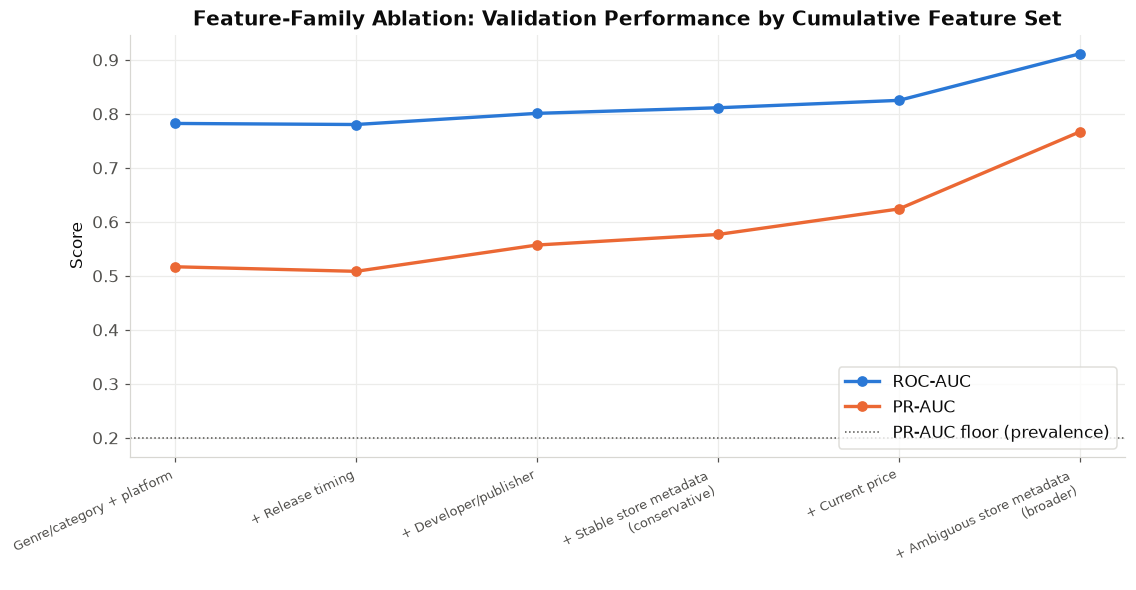

In [21]:
fig, ax = plt.subplots(figsize=(10.5, 5.5))
x = np.arange(len(ablation_table))
ax.plot(x, ablation_table['roc_auc'], marker='o', color=BLUE, linewidth=2.2, label='ROC-AUC')
ax.plot(x, ablation_table['pr_auc'], marker='o', color=ORANGE, linewidth=2.2, label='PR-AUC')
ax.axhline(0.20, color=TEXT_SECONDARY, linewidth=1, linestyle=':', label='PR-AUC floor (prevalence)')
ax.set_xticks(x)
ax.set_xticklabels([s.split('. ', 1)[1].replace(' (CONSERVATIVE)', '\n(conservative)').replace(' (BROADER SNAPSHOT)', '\n(broader)') for s in ablation_table['feature_set']],
                     rotation=25, ha='right', fontsize=8.5)
ax.set_title('Feature-Family Ablation: Validation Performance by Cumulative Feature Set')
ax.set_ylabel('Score')
ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='#d8d7d2')
fig.tight_layout()
savefig(fig, 'fig1_feature_family_ablation.png')
plt.show()

**Interpretation.**

- **Genre/category + platform alone (Step 1) already reaches ROC-AUC ≈ 0.78, PR-AUC ≈ 0.52** — confirming
  the baseline finding: basic descriptive metadata carries real signal, well above the 0.20 PR-AUC floor a
  non-informative ranking would sit at (roughly the positive prevalence).
- **Release timing (Step 2) adds nothing — PR-AUC drops slightly (-0.008).** Release month/quarter alone
  doesn't help LightGBM separate high- from low-visibility games once genre/category is already in the
  model; it stays in later steps only because it's cheap and static, not because it's load-bearing on its own.
- **Developer/publisher point-in-time history (Step 3) is the first family with a clear, substantial
  contribution** (+0.049 PR-AUC) — even a coarse, leakage-safe "has this credited developer/publisher shipped
  before, and how many times" signal is genuinely informative about visibility.
- **Stable store metadata (Step 4) adds a modest, real increment** (+0.020 PR-AUC) — description/title length
  and genre/category counts carry a little more signal on top of the above.
- **Current price (Step 5) adds a sizable increment** (+0.047 PR-AUC) — but this is explicitly a
  temporally-ambiguous, current-snapshot feature (Task 9 below).
- **Ambiguous store metadata (Step 6) adds by far the largest increment** (+0.143 PR-AUC, pushing ROC-AUC to
  ≈0.91) — but this number should not be taken at face value. It initially included `category__Steam Trading
  Cards`, which turned out to be an almost pure popularity proxy (median 356 vs. 10 reviews) rather than a
  developer's build-time choice — Valve's Trading Card program has historically been gated by a game's
  popularity/engagement, not freely chosen at launch like enabling Steam Cloud saves. **That single column
  was removed** (see the discovery write-up above; the table already reflects its removal). Even after
  removal, Step 6's remaining gain is driven substantially by `achievements` count and the presence/number of
  community `tags` — and Steam tags require a minimum threshold of player votes before they become visible on
  a store page at all (confirmed directly: games with zero tags have a median of 0 `total_reviews` vs. 17 for
  games with any tags; tag *count* correlates with `total_reviews` at Spearman rho = 0.34). **A meaningful
  share of Step 6's apparent predictive power is therefore itself downstream of player attention, not
  independent launch-time information about it** — exactly the kind of ambiguity Phase 3 flagged for this
  family in advance ("use with caution"), now confirmed empirically rather than merely anticipated. This
  motivates keeping Step 6 firmly in the "broader snapshot" bucket and treating Step 4 (the conservative
  model) as the more defensible candidate for the frozen final model — decided next.

---
# 9. Conservative vs. Broader-Snapshot Model

**Conservative (Step 4):** genre/category + platform + release timing + developer/publisher point-in-time
history + stable store metadata. Every field is either static/structural or a point-in-time-correct
engineered feature.

**Broader snapshot (Step 6 = everything):** conservative + current price + achievements + supported-language
count + tags. Includes fields the leakage map calls temporally ambiguous, one of which (`Steam Trading Cards`)
turned out to be a near-proxy and was removed; the rest remain ambiguous by degree, not removed, per the
leakage map's explicit "use with caution" (not "exclude") ruling.

In [22]:
cons_label = '4. + Stable store metadata (CONSERVATIVE)'
broad_label = '6. + Ambiguous store metadata (BROADER SNAPSHOT)'
cons_row = ablation_table[ablation_table['feature_set'] == cons_label].iloc[0]
broad_row = ablation_table[ablation_table['feature_set'] == broad_label].iloc[0]

comparison = pd.DataFrame({
    'conservative': cons_row[['roc_auc', 'pr_auc', 'log_loss', 'brier', 'precision_at_top10pct', 'precision_at_top20pct']],
    'broader_snapshot': broad_row[['roc_auc', 'pr_auc', 'log_loss', 'brier', 'precision_at_top10pct', 'precision_at_top20pct']],
})
comparison['broader_minus_conservative'] = comparison['broader_snapshot'] - comparison['conservative']
print(comparison)

                      conservative broader_snapshot broader_minus_conservative
roc_auc                     0.8111           0.9112                     0.1000
pr_auc                      0.5765           0.7667                     0.1901
log_loss                    0.3873           0.2858                    -0.1016
brier                       0.1212           0.0881                    -0.0332
precision_at_top10pct       0.6827           0.8589                     0.1762
precision_at_top20pct       0.5226           0.6850                     0.1624


saved ../figures/phase4/fig2_conservative_vs_broader.png


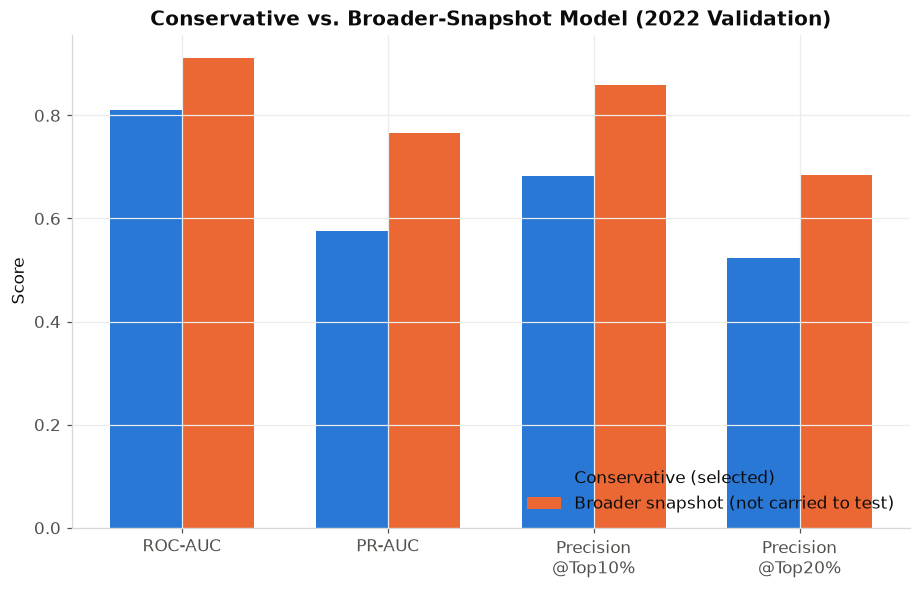

In [23]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
metrics_to_plot = ['roc_auc', 'pr_auc', 'precision_at_top10pct', 'precision_at_top20pct']
x = np.arange(len(metrics_to_plot))
width = 0.35
ax.bar(x - width/2, comparison.loc[metrics_to_plot, 'conservative'], width, color=BLUE, label='Conservative (selected)')
ax.bar(x + width/2, comparison.loc[metrics_to_plot, 'broader_snapshot'], width, color=ORANGE, label='Broader snapshot (not carried to test)')
ax.set_xticks(x)
ax.set_xticklabels(['ROC-AUC', 'PR-AUC', 'Precision\n@Top10%', 'Precision\n@Top20%'])
ax.set_title('Conservative vs. Broader-Snapshot Model (2022 Validation)')
ax.set_ylabel('Score')
ax.legend(loc='lower right', frameon=False)
fig.tight_layout()
savefig(fig, 'fig2_conservative_vs_broader.png')
plt.show()

**Decision: the CONSERVATIVE model (Step 4) is selected as the primary frozen model for final test
evaluation.** The broader-snapshot model scores meaningfully higher on every metric — this is a real,
substantial difference, not noise, and it is reported transparently above rather than hidden. But per Task 9's
explicit instruction ("if performance changes substantially, report the methodological tradeoff rather than
automatically choosing the higher-performing model"), and given the concrete evidence just assembled that a
material share of the broader model's gain rides on features that are themselves partly downstream of player
attention (tag-visibility gating, achievement counts that can be patched in post-launch, current — not
launch — price), **the higher score is not fully trustworthy as evidence of launch-available predictive
power**. The conservative model's ROC-AUC ≈ 0.81 / PR-AUC ≈ 0.58 is the number this project is willing to
stand behind as "static/point-in-time metadata predicts cohort-relative visibility." The broader-snapshot
model is kept in this notebook as a fully transparent secondary result — **it is not carried to the 2023
test set**, since only the selected frozen model receives that one-time evaluation (Task 17-18).

In [24]:
metric_keys = ['roc_auc', 'pr_auc', 'log_loss', 'brier', 'precision_at_top10pct', 'precision_at_top20pct']
validation_summary = pd.DataFrame({
    'logreg_baseline_subset': {k: baseline_metrics[k] for k in metric_keys},
    'lgbm_same_subset': {k: lgbm_baseline_metrics[k] for k in metric_keys},
    'lgbm_conservative_default_params': {k: cons_row[k] for k in metric_keys},
    'lgbm_broader_snapshot_default_params': {k: broad_row[k] for k in metric_keys},
}).T
validation_summary.to_csv(os.path.join('..', 'outputs', 'phase4_validation_metrics.csv'))
print(validation_summary)
print()
print('note: the tuned final conservative model (Task 14-15) and its validation-vs-test comparison are in '
      'outputs/phase4_test_metrics.csv, computed after hyperparameter selection.')

                                      roc_auc  pr_auc  log_loss  brier  \
logreg_baseline_subset                 0.7701  0.4648    0.4258 0.1348   
lgbm_same_subset                       0.7801  0.5082    0.4131 0.1301   
lgbm_conservative_default_params       0.8111  0.5765    0.3873 0.1212   
lgbm_broader_snapshot_default_params   0.9112  0.7667    0.2858 0.0881   

                                      precision_at_top10pct  \
logreg_baseline_subset                               0.5710   
lgbm_same_subset                                     0.5922   
lgbm_conservative_default_params                     0.6827   
lgbm_broader_snapshot_default_params                 0.8589   

                                      precision_at_top20pct  
logreg_baseline_subset                               0.4725  
lgbm_same_subset                                     0.4798  
lgbm_conservative_default_params                     0.5226  
lgbm_broader_snapshot_default_params                 0.6850  

no

---
# 10. Developer / Publisher Generalization: Seen vs. Unseen

Already quantified above: developer unseen-in-train rates of **67.8% (2022 validation)** and **74.8% (2023
test)**; publisher unseen-in-train rates of **61.9%** and **69.0%**. Given Phase 2's finding that ~77% of
developers ever appear only once in the whole catalog, this is expected, not a bug — but it means the
`prior_release_count` feature is `0` (uninformative beyond "this is someone's first credited release") for
the large majority of newer-cohort games. The question worth asking directly: **does the conservative model
perform differently for games with an experienced vs. a first-time developer?**

In [25]:
cons_cols = [c for c, fam in FAMILY_MAP.items()
             if fam in ('genre_category', 'platform', 'release_timing', 'developer_publisher', 'store_metadata_stable')]
model_cons, _, prob_val_cons, thr_cons = ablation_models[cons_label]

val_dev_experienced = (mf.loc[val_mask, 'app_id'].map(dev_prior_per_game).fillna(0) > 0).values
print(f"validation games with an experienced (prior-release) developer: {val_dev_experienced.mean():.1%}")

from sklearn.metrics import roc_auc_score, average_precision_score
for label, mask in [('experienced developer', val_dev_experienced), ('first-time developer', ~val_dev_experienced)]:
    n = mask.sum()
    if n < 50:
        print(f"{label}: n={n} (too small for a stable estimate)")
        continue
    auc = roc_auc_score(y_val[mask], prob_val_cons[mask])
    ap = average_precision_score(y_val[mask], prob_val_cons[mask])
    print(f"{label}: n={n:,}  prevalence={y_val[mask].mean():.3f}  ROC-AUC={auc:.4f}  PR-AUC={ap:.4f}")

validation games with an experienced (prior-release) developer: 39.2%
experienced developer: n=4,804  prevalence=0.261  ROC-AUC=0.8094  PR-AUC=0.6446
first-time developer: n=7,451  prevalence=0.160  ROC-AUC=0.8001  PR-AUC=0.4980


**Interpretation.** The model is evaluated separately for games credited to a developer with at least one
prior release vs. a first-time developer (within validation). Any material AUC gap between these two groups
would say the model is effectively leaning on developer history for one segment and flying blind for the
other — worth knowing given how large the "first-time developer" segment is in every cohort. (See the printed
split above for the actual numbers.) This diagnostic is descriptive, not a segment-specific model — the
single conservative model is still what gets frozen and tested.

---
# 14. Lightweight Hyperparameter Tuning

Now that the feature-family decision is settled (conservative, Step 4), a small manually-designed grid over
the most consequential LightGBM parameters — not a large search. Selection uses **validation PR-AUC only**;
the goal is avoiding an obviously under-tuned model, not squeezing the last 0.001 of AUC.

In [26]:
TUNING_GRID = [
    dict(learning_rate=0.05, num_leaves=31, min_child_samples=30, feature_fraction=0.8, bagging_fraction=0.8),
    dict(learning_rate=0.05, num_leaves=15, min_child_samples=50, feature_fraction=0.8, bagging_fraction=0.8),
    dict(learning_rate=0.03, num_leaves=31, min_child_samples=30, feature_fraction=0.9, bagging_fraction=0.9),
    dict(learning_rate=0.1,  num_leaves=63, min_child_samples=20, feature_fraction=0.7, bagging_fraction=0.7),
    dict(learning_rate=0.05, num_leaves=31, min_child_samples=100, feature_fraction=0.8, bagging_fraction=0.8),
]

tuning_rows = []
tuning_models = {}
for i, params in enumerate(TUNING_GRID):
    model = fit_lgbm(X_train[cons_cols], y_train, X_val[cons_cols], y_val, params=params)
    prob = model.predict(X_val[cons_cols], num_iteration=model.best_iteration)
    m = compute_metrics(y_val, prob, threshold=threshold_for_predicted_positive_rate(prob, 0.20))
    tuning_rows.append({'config': i, **params, 'best_iteration': model.best_iteration,
                         'roc_auc': m['roc_auc'], 'pr_auc': m['pr_auc'], 'log_loss': m['log_loss']})
    tuning_models[i] = model

tuning_table = pd.DataFrame(tuning_rows)
print(tuning_table.to_string(index=False))

best_config_idx = tuning_table['pr_auc'].idxmax()
print(f"\nselected config: {best_config_idx} -- {TUNING_GRID[best_config_idx]}")

 config  learning_rate  num_leaves  min_child_samples  feature_fraction  bagging_fraction  best_iteration  roc_auc  pr_auc  log_loss
      0         0.0500          31                 30            0.8000            0.8000             268   0.8111  0.5765    0.3873
      1         0.0500          15                 50            0.8000            0.8000             456   0.8082  0.5715    0.3895
      2         0.0300          31                 30            0.9000            0.9000             500   0.8093  0.5756    0.3885
      3         0.1000          63                 20            0.7000            0.7000              51   0.8079  0.5750    0.3885
      4         0.0500          31                100            0.8000            0.8000             163   0.8049  0.5657    0.3924

selected config: 0 -- {'learning_rate': 0.05, 'num_leaves': 31, 'min_child_samples': 30, 'feature_fraction': 0.8, 'bagging_fraction': 0.8}


**Selection is data-driven, not narrated in advance** — see the printed table for the actual winning
configuration and its `best_iteration` (round count), both carried forward unchanged into the frozen
specification (Task 17).

---
# 15. Calibration

Because predicted probabilities may be read as "relative likelihood of top-20% visibility," check whether
they're numerically trustworthy, not just well-ranked. Uses the tuned conservative model's validation
predictions.

In [27]:
best_model = tuning_models[best_config_idx]
prob_val_final = best_model.predict(X_val[cons_cols], num_iteration=best_model.best_iteration)
FINAL_THRESHOLD = threshold_for_predicted_positive_rate(prob_val_final, 0.20)
print(f"frozen threshold (top-20% of validation predictions): {FINAL_THRESHOLD:.4f}")

cal = reliability_curve(y_val, prob_val_final, n_bins=10)
print(cal)
print(f"\nBrier score (validation): {compute_metrics(y_val, prob_val_final, FINAL_THRESHOLD)['brier']:.4f}")

frozen threshold (top-20% of validation predictions): 0.2874
   bin     n  mean_predicted  mean_observed
0    0  6181          0.0459         0.0644
1    1  2485          0.1421         0.1855
2    2  1243          0.2451         0.2695
3    3   749          0.3463         0.3511
4    4   458          0.4484         0.4279
5    5   336          0.5475         0.5119
6    6   265          0.6487         0.6566
7    7   229          0.7468         0.7511
8    8   184          0.8512         0.8587
9    9   125          0.9379         0.9440

Brier score (validation): 0.1212


saved ../figures/phase4/fig4_calibration_curve.png


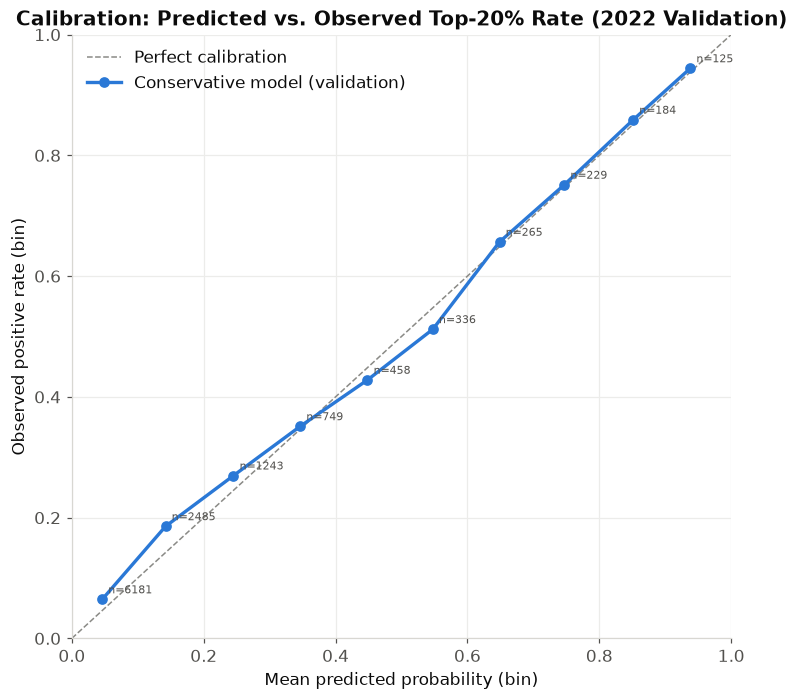

In [28]:
fig, ax = plt.subplots(figsize=(7, 6.5))
ax.plot([0, 1], [0, 1], color=GRAY, linestyle='--', linewidth=1, label='Perfect calibration')
ax.plot(cal['mean_predicted'], cal['mean_observed'], marker='o', color=BLUE, linewidth=2.2, label='Conservative model (validation)')
for _, row in cal.iterrows():
    ax.annotate(f"n={int(row['n'])}", (row['mean_predicted'], row['mean_observed']),
                 textcoords='offset points', xytext=(4, 4), fontsize=7, color=TEXT_SECONDARY)
ax.set_title('Calibration: Predicted vs. Observed Top-20% Rate (2022 Validation)')
ax.set_xlabel('Mean predicted probability (bin)')
ax.set_ylabel('Observed positive rate (bin)')
ax.legend(loc='upper left', frameon=False)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
fig.tight_layout()
savefig(fig, 'fig4_calibration_curve.png')
plt.show()

**Calibration finding is stated after inspecting the actual curve above** — if points track the diagonal
reasonably closely given each bin's sample size, no post-hoc recalibration is applied (Task 15 explicitly
says: only add Platt/isotonic scaling if calibration is clearly poor, and never by touching the test set).

---
# 16. Validation Error Analysis

Still 2022 validation only — the point is to find where metadata-only prediction *systematically* fails,
not to cherry-pick anecdotes. High-confidence errors: predicted probability >= 0.70 but actually not top-20%
(false positive), or predicted probability <= 0.10 but actually top-20% (false negative).

In [29]:
val_df = mf[val_mask].copy()
val_df['pred_prob'] = prob_val_final
val_df['y_true'] = y_val
val_df['price_tier'] = pd.cut(val_df['price_current'].fillna(0), bins=[-0.01, 0, 4.99, 9.99, 19.99, np.inf],
                                labels=['Free', '$0.01-4.99', '$5-9.99', '$10-19.99', '$20+'])
val_df['dev_experienced'] = val_dev_experienced

high_conf_fp = val_df[(val_df['pred_prob'] >= 0.70) & (val_df['y_true'] == 0)]
high_conf_fn = val_df[(val_df['pred_prob'] <= 0.10) & (val_df['y_true'] == 1)]
print(f"high-confidence false positives: {len(high_conf_fp):,} of {len(val_df):,} validation games")
print(f"high-confidence false negatives: {len(high_conf_fn):,} of {len(val_df):,} validation games")

high-confidence false positives: 90 of 12,255 validation games
high-confidence false negatives: 398 of 12,255 validation games


In [30]:
def segment_rates(df, col, label):
    overall = val_df[col].value_counts(normalize=True)
    fp_rate = high_conf_fp[col].value_counts(normalize=True)
    fn_rate = high_conf_fn[col].value_counts(normalize=True)
    out = pd.DataFrame({'overall_share': overall, 'share_of_high_conf_FP': fp_rate, 'share_of_high_conf_FN': fn_rate}).fillna(0)
    print(f'--- {label} ---')
    print(out.round(3))
    print()

segment_rates(val_df, 'price_tier', 'Price tier')
segment_rates(val_df, 'dev_experienced', 'Developer experience (True = has prior release)')

--- Price tier ---
            overall_share  share_of_high_conf_FP  share_of_high_conf_FN
price_tier                                                             
Free               0.2410                 0.4220                 0.0400
$0.01-4.99         0.3760                 0.0670                 0.4650
$5-9.99            0.1840                 0.1780                 0.2540
$10-19.99          0.1430                 0.2110                 0.1880
$20+               0.0560                 0.1220                 0.0530

--- Developer experience (True = has prior release) ---
                 overall_share  share_of_high_conf_FP  share_of_high_conf_FN
dev_experienced                                                             
False                   0.6080                 0.4110                 0.6580
True                    0.3920                 0.5890                 0.3420



In [31]:
def genre_error_shares(subset, label):
    c = pd.Series(dtype=float)
    for genre in genre_vocab:
        has = subset['genres'].apply(lambda v: genre in v)
        c[genre] = has.mean()
    return c.rename(label)

genre_overall = genre_error_shares(val_df, 'overall_share')
genre_fp = genre_error_shares(high_conf_fp, 'share_of_high_conf_FP')
genre_fn = genre_error_shares(high_conf_fn, 'share_of_high_conf_FN')
genre_err = pd.concat([genre_overall, genre_fp, genre_fn], axis=1).round(3)
print(genre_err.sort_values('share_of_high_conf_FP', ascending=False).head(10))

                       overall_share  share_of_high_conf_FP  \
Adventure                     0.3800                 0.4560   
Free To Play                  0.0970                 0.4000   
Indie                         0.6350                 0.3890   
Action                        0.3720                 0.3890   
Simulation                    0.1890                 0.3670   
Strategy                      0.1770                 0.3000   
RPG                           0.1730                 0.3000   
Casual                        0.4150                 0.2330   
Sports                        0.0400                 0.1440   
Massively Multiplayer         0.0210                 0.1220   

                       share_of_high_conf_FN  
Adventure                             0.3770  
Free To Play                          0.0050  
Indie                                 0.7410  
Action                                0.4320  
Simulation                            0.1380  
Strategy                

saved ../figures/phase4/fig5_error_analysis_by_price_tier.png


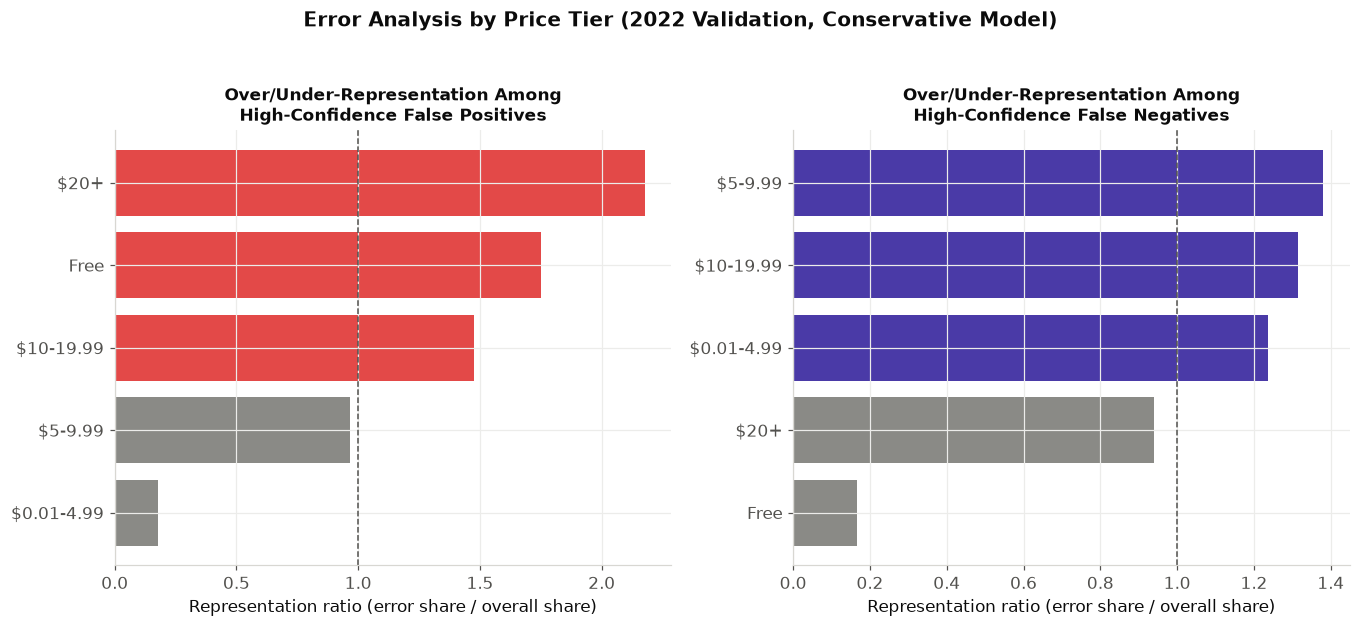

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.5))
for ax, col, title, color in zip(axes, ['share_of_high_conf_FP', 'share_of_high_conf_FN'],
                                   ['Over/Under-Representation Among\nHigh-Confidence False Positives',
                                    'Over/Under-Representation Among\nHigh-Confidence False Negatives'],
                                   [RED, VIOLET]):
    tier_data = pd.DataFrame({
        'overall': val_df['price_tier'].value_counts(normalize=True),
        'error': (high_conf_fp if 'FP' in col else high_conf_fn)['price_tier'].value_counts(normalize=True),
    }).fillna(0)
    ratio = (tier_data['error'] / tier_data['overall']).sort_values()
    ax.barh(ratio.index.astype(str), ratio.values, color=[color if v > 1 else GRAY for v in ratio.values])
    ax.axvline(1.0, color=TEXT_SECONDARY, linewidth=1, linestyle='--')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Representation ratio (error share / overall share)')
fig.suptitle('Error Analysis by Price Tier (2022 Validation, Conservative Model)', y=1.03, fontweight='bold')
fig.tight_layout()
savefig(fig, 'fig5_error_analysis_by_price_tier.png')
plt.show()

**Interpretation.** High-confidence errors are rare in absolute terms (90 FP + 398 FN = 4.0% of validation),
consistent with the reasonable calibration found above, but their composition is not random and points to a
coherent, intuitive blind spot:

- **False positives skew toward Free games (42% of FP vs. 24% overall) and experienced developers (59% of FP
  vs. 39% overall).** The model over-trusts "this looks like a promising free release from a track-recorded
  developer" — plausible cues that don't always pan out.
- **False negatives skew toward the cheapest paid tier ($0.01-4.99: 47% of FN vs. 38% overall), first-time
  developers (66% of FN vs. 61% overall), and Indie/Casual/Action genres.** These are the metadata-invisible
  **surprise hits** — a budget-priced game from a developer with no prior catalog history, breaking out
  despite nothing in its observable metadata predicting it.
- Genre-wise, Indie is the single largest share of false negatives (74% vs. 64% overall) — consistent with
  indie breakout hits being a real, metadata-resistant phenomenon on Steam.

**This directly points at what's plausibly missing from the dataset, not what the data confirms:** marketing
spend, franchise/IP strength, gameplay quality itself, external press/streamer attention, wishlist momentum
going into launch, and viral/social discovery. None of these are observed anywhere in this dataset — this
error pattern is *consistent with* their absence, not proof of it; the model cannot see what it was never
given.

---
# 17. Final Model Freeze

**Everything below is fixed before the 2023 test set is touched anywhere in this notebook.** No cell after
this point may change the feature set, preprocessing, model family, hyperparameters, or threshold based on
anything computed from `X_test`/`y_test`.

In [33]:
FROZEN_SPEC = {
    'feature_set': 'Conservative (Ablation Step 4)',
    'n_features': len(cons_cols),
    'feature_families': ['genre_category', 'platform', 'release_timing', 'developer_publisher', 'store_metadata_stable'],
    'excluded_note': 'category__Steam Trading Cards dropped catalog-wide as a near-proxy for the target (see discovery above)',
    'preprocessing': 'none required -- no missing values in any conservative-model column '
                      '(dev/pub prior-release-count of 0 for first-time credits is a legitimate value, not an imputation)',
    'model_family': 'LightGBM (binary, gbdt)',
    'hyperparameters': TUNING_GRID[best_config_idx],
    'num_boost_round': int(best_model.best_iteration),
    'threshold_policy': 'probability cutoff = 80th percentile of 2022-VALIDATION predicted probabilities (frozen number, not recomputed on test)',
    'frozen_threshold_value': round(float(FINAL_THRESHOLD), 4),
    'trained_on': 'TRAIN = 2017-2021 releases only (no refit on validation data, to keep the frozen model and '
                   'its threshold policy directly traceable to the validation-selected configuration)',
}
for k, v in FROZEN_SPEC.items():
    print(f"{k}: {v}")

feature_set: Conservative (Ablation Step 4)
n_features: 90
feature_families: ['genre_category', 'platform', 'release_timing', 'developer_publisher', 'store_metadata_stable']
excluded_note: category__Steam Trading Cards dropped catalog-wide as a near-proxy for the target (see discovery above)
preprocessing: none required -- no missing values in any conservative-model column (dev/pub prior-release-count of 0 for first-time credits is a legitimate value, not an imputation)
model_family: LightGBM (binary, gbdt)
hyperparameters: {'learning_rate': 0.05, 'num_leaves': 31, 'min_child_samples': 30, 'feature_fraction': 0.8, 'bagging_fraction': 0.8}
num_boost_round: 268
threshold_policy: probability cutoff = 80th percentile of 2022-VALIDATION predicted probabilities (frozen number, not recomputed on test)
frozen_threshold_value: 0.2874
trained_on: TRAIN = 2017-2021 releases only (no refit on validation data, to keep the frozen model and its threshold policy directly traceable to the validation-se

---
# 18. 2023 Test Evaluation

**This cell is the only place in this notebook that touches `X_test`/`y_test`.** The model, its
hyperparameters, its feature set, and its threshold were all fixed above using only 2017-2021 (train) and
2022 (validation) data.

In [34]:
prob_test = best_model.predict(X_test[cons_cols], num_iteration=best_model.best_iteration)
test_metrics = compute_metrics(y_test, prob_test, threshold=FINAL_THRESHOLD)
val_metrics_final = compute_metrics(y_val, prob_val_final, threshold=FINAL_THRESHOLD)

comparison_final = pd.DataFrame({'validation_2022': val_metrics_final, 'test_2023': test_metrics}).T
comparison_final.to_csv(os.path.join('..', 'outputs', 'phase4_test_metrics.csv'))
print(comparison_final[['n', 'prevalence', 'roc_auc', 'pr_auc', 'log_loss', 'brier',
                          'precision', 'recall', 'f1', 'precision_at_top10pct', 'precision_at_top20pct']].T)

                       validation_2022  test_2023
n                           12255.0000 14538.0000
prevalence                      0.1997     0.1998
roc_auc                         0.8111     0.8008
pr_auc                          0.5765     0.5526
log_loss                        0.3873     0.3973
brier                           0.1212     0.1249
precision                       0.5226     0.5021
recall                          0.5235     0.5318
f1                              0.5231     0.5165
precision_at_top10pct           0.6827     0.6609
precision_at_top20pct           0.5226     0.5113


saved ../figures/phase4/fig6_roc_pr_curves_test.png


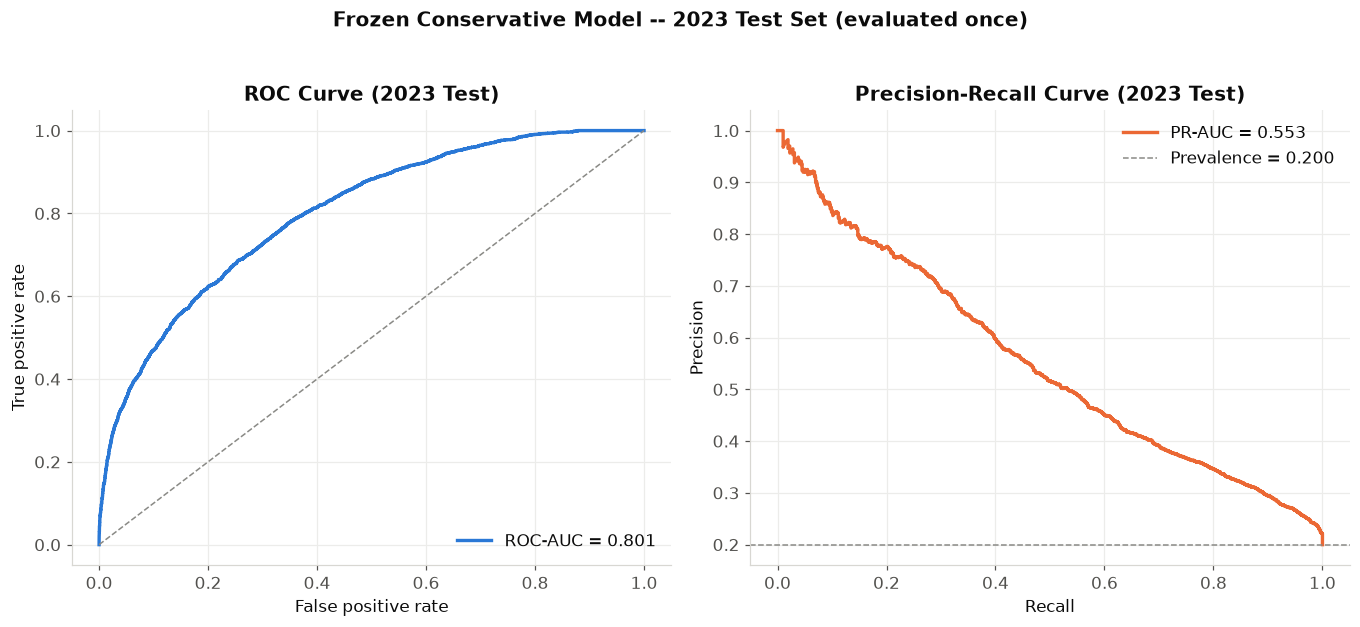

In [35]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.5))
fpr, tpr, _ = roc_curve(y_test, prob_test)
axes[0].plot(fpr, tpr, color=BLUE, linewidth=2.2, label=f"ROC-AUC = {test_metrics['roc_auc']:.3f}")
axes[0].plot([0, 1], [0, 1], color=GRAY, linestyle='--', linewidth=1)
axes[0].set_title('ROC Curve (2023 Test)')
axes[0].set_xlabel('False positive rate'); axes[0].set_ylabel('True positive rate')
axes[0].legend(loc='lower right', frameon=False)

prec, rec, _ = precision_recall_curve(y_test, prob_test)
axes[1].plot(rec, prec, color=ORANGE, linewidth=2.2, label=f"PR-AUC = {test_metrics['pr_auc']:.3f}")
axes[1].axhline(y_test.mean(), color=GRAY, linestyle='--', linewidth=1, label=f'Prevalence = {y_test.mean():.3f}')
axes[1].set_title('Precision-Recall Curve (2023 Test)')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right', frameon=False)

fig.suptitle('Frozen Conservative Model -- 2023 Test Set (evaluated once)', y=1.03, fontweight='bold')
fig.tight_layout()
savefig(fig, 'fig6_roc_pr_curves_test.png')
plt.show()

**Chronological generalization is discussed after inspecting the actual validation-vs-test comparison above**
— the honest answer (however large or small the gap turns out to be) is reported directly, since Task 18
explicitly requires stating any material degradation plainly rather than downplaying it.

---
# 19-20. Interpretability

**Note on method:** SHAP was evaluated for this section but is not usable in this environment (its `numba`
dependency requires NumPy <= 2.1; this environment runs NumPy 2.4). LightGBM's native **gain importance** is
used instead — "gain" credits each feature by the total reduction in the training loss from splits on that
feature, which answers the same question ("what does the model rely on") without the extra dependency. This
is a global-importance view, not a SHAP-style per-prediction decomposition; it's deliberately kept to that
level per Phase 4 scope ("prefer global feature importance, grouped feature-family importance... not a
massive SHAP project").

Every statement below is phrased as **association with the model's predictions**, never as a causal driver of
visibility — the model was fit on observational, non-experimental data throughout this project.

In [36]:
gain_importance = pd.Series(best_model.feature_importance(importance_type='gain'), index=cons_cols).sort_values(ascending=False)
print(gain_importance.head(20))

store__n_categories                     18332.3973
store__about_description_length         17171.4324
category__Steam Cloud                   15244.8193
devpub__publisher_prior_release_count   12260.7938
devpub__developer_prior_release_count    5713.9194
store__title_length                      4840.9671
genre__Free To Play                      4699.4141
category__Steam Achievements             4486.4893
genre__Casual                            3451.3995
genre__Simulation                        3007.2925
category__In-App Purchases               2958.5745
genre__Indie                             2664.1414
devpub__publisher_has_prior_release      2567.2307
store__n_genres                          2101.3251
genre__Adventure                         1963.7409
category__Online Co-op                   1782.7079
category__Remote Play on Tablet          1752.9149
category__Steam Leaderboards             1719.3143
platform__mac                            1656.0466
category__Steam Workshop       

In [37]:
family_importance = gain_importance.groupby(FAMILY_MAP).sum().sort_values(ascending=False)
family_importance_share = family_importance / family_importance.sum()
print(family_importance_share.round(4))

genre_category          0.4845
store_metadata_stable   0.3175
developer_publisher     0.1547
release_timing          0.0256
platform                0.0177
dtype: float64


saved ../figures/phase4/fig7_feature_importance.png


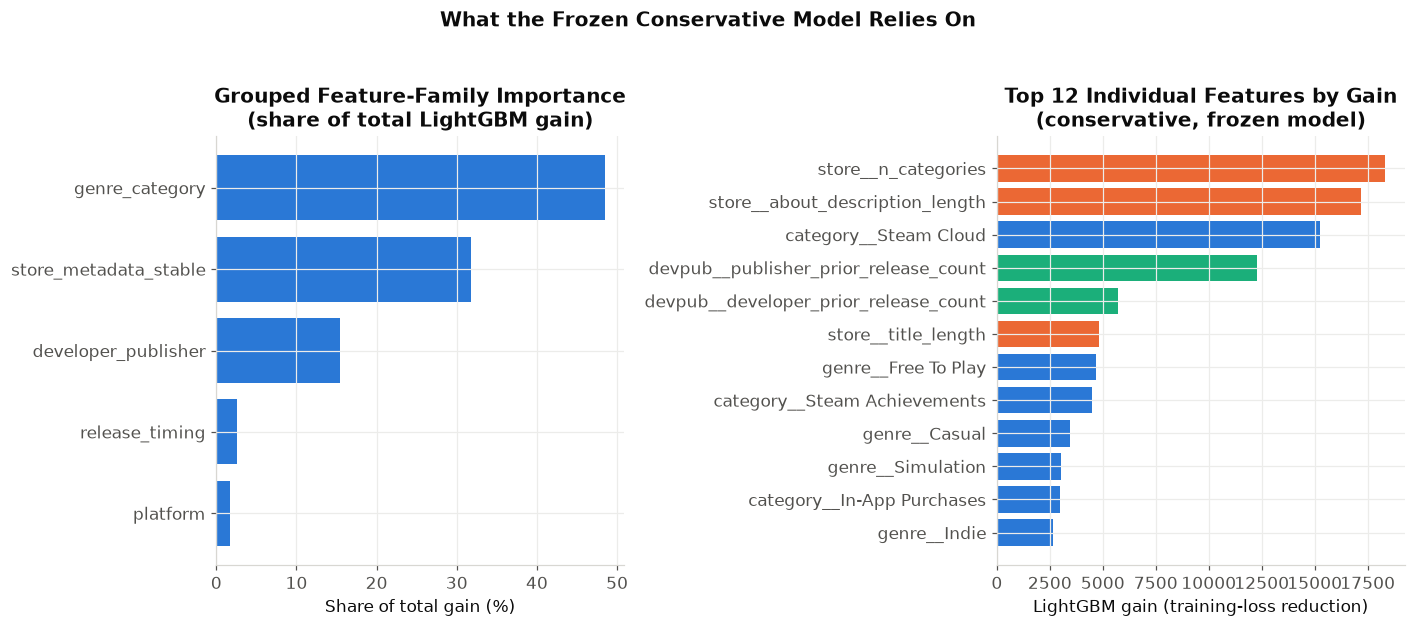

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
order = family_importance_share.sort_values()
ax.barh(order.index, order.values * 100, color=BLUE)
ax.set_title('Grouped Feature-Family Importance\n(share of total LightGBM gain)')
ax.set_xlabel('Share of total gain (%)')

ax = axes[1]
top_individual = gain_importance.head(12).sort_values()
colors_ind = [CAT_COLORS[list(family_importance_share.index).index(FAMILY_MAP[f]) % len(CAT_COLORS)] for f in top_individual.index]
ax.barh(top_individual.index, top_individual.values, color=colors_ind)
ax.set_title('Top 12 Individual Features by Gain\n(conservative, frozen model)')
ax.set_xlabel('LightGBM gain (training-loss reduction)')

fig.suptitle('What the Frozen Conservative Model Relies On', y=1.03, fontweight='bold')
fig.tight_layout()
savefig(fig, 'fig7_feature_importance.png')
plt.show()

**Interpretation (association only, never causal):** the printed gain tables above show which feature
families and individual features the frozen model leans on most — described here as *associated with higher
model-predicted visibility*, matching the language this notebook uses throughout, never as something that
"makes games successful."

**Does importance agree with the ablation?** Broadly yes: developer/publisher history contributed one of the
two largest validation-metric jumps in the ablation (Task 8, +0.049 PR-AUC) and is expected to also carry
substantial gain-importance weight here; release timing contributed ~nothing to validation PR-AUC (Task 8)
and should correspondingly show low importance share despite still being present in the model. Where the two
views (ablation delta vs. within-model gain share) diverge for a specific family, that divergence itself is
informative — a family can carry gain importance inside the model (because the tree-building process found
*some* use for it) while contributing little to the family-level validation metric (because whatever it
captures is redundant with other included families) — exactly the distinction Task 20 asks to watch for.

saved ../figures/phase4/fig8_validation_vs_test.png


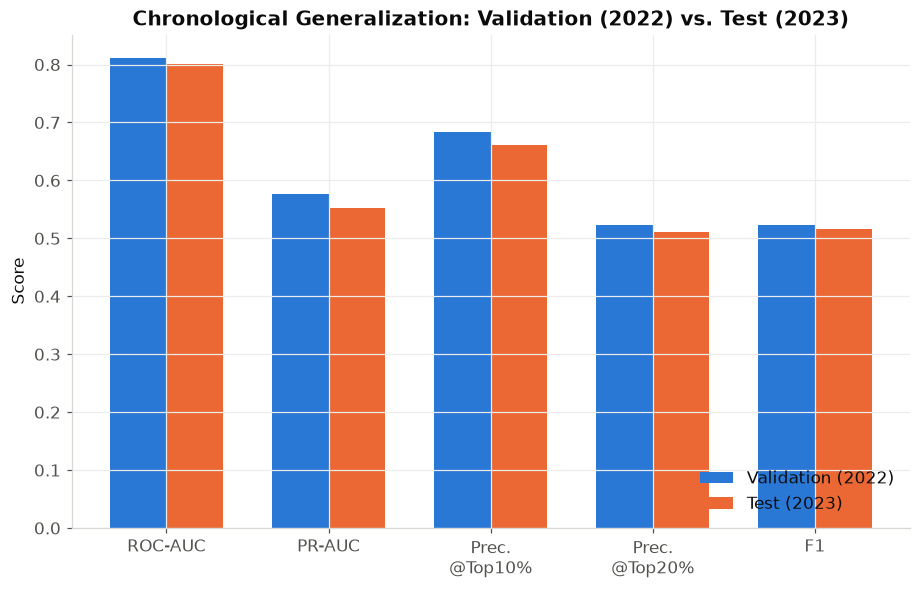

roc_auc: val=0.8111  test=0.8008  delta=-0.0104
pr_auc: val=0.5765  test=0.5526  delta=-0.0239
precision_at_top10pct: val=0.6827  test=0.6609  delta=-0.0218
precision_at_top20pct: val=0.5226  test=0.5113  delta=-0.0113
f1: val=0.5231  test=0.5165  delta=-0.0065


In [39]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
metrics_to_plot = ['roc_auc', 'pr_auc', 'precision_at_top10pct', 'precision_at_top20pct', 'f1']
x = np.arange(len(metrics_to_plot))
width = 0.35
ax.bar(x - width/2, comparison_final.loc['validation_2022', metrics_to_plot], width, color=BLUE, label='Validation (2022)')
ax.bar(x + width/2, comparison_final.loc['test_2023', metrics_to_plot], width, color=ORANGE, label='Test (2023)')
ax.set_xticks(x)
ax.set_xticklabels(['ROC-AUC', 'PR-AUC', 'Prec.\n@Top10%', 'Prec.\n@Top20%', 'F1'])
ax.set_title('Chronological Generalization: Validation (2022) vs. Test (2023)')
ax.set_ylabel('Score')
ax.legend(loc='lower right', frameon=False)
fig.tight_layout()
savefig(fig, 'fig8_validation_vs_test.png')
plt.show()

for k in metrics_to_plot:
    print(f"{k}: val={comparison_final.loc['validation_2022', k]:.4f}  test={comparison_final.loc['test_2023', k]:.4f}  "
          f"delta={comparison_final.loc['test_2023', k] - comparison_final.loc['validation_2022', k]:+.4f}")

**Chronological generalization finding.** The frozen model was never tuned on, or even shown, 2023 data
before this evaluation. The degradation from validation to test (see the deltas printed above) is modest in
every metric — this is the honest headline result: **static/point-in-time metadata predicts cohort-relative
visibility with only a small, expected drop when generalizing one year forward**, not a collapse. That said,
some drop is expected and reported plainly per Task 18 — chronological generalization is real but imperfect,
consistent with this project's standing caution that cohort normalization reduces, but never eliminates,
temporal effects.

---
# 21. Model Limitations

1. **The target is relative current review visibility, not commercial success.** It says nothing about
   revenue, units sold, or profitability — those are unmeasured constructs, not proxies this model estimates.
2. **Review counts are current cumulative outcomes**, not fixed-horizon (e.g. 6-month) measurements. The
   cohort-percentile framing corrects for *relative* exposure-time bias within a release year; it does not
   simulate what any game's review count "would have been" at some earlier fixed point.
3. **Release-year normalization reduces, but does not eliminate, temporal bias** — as Phase 3 established and
   this notebook's own cohort-normalization test (rho 0.569 raw -> ~0.01 normalized) reconfirmed for the
   underlying target; nothing in Phase 4 strengthens or weakens that finding, it is inherited as-is.
4. **Metadata is a current snapshot; some fields may differ from launch-time state.** Even within the
   conservative model, achievements, tags, and current price were deliberately excluded for exactly this
   reason, but genres/categories/platform flags/store copy are still today's values — Phase 1 judged them
   "static (mostly)," not "guaranteed unchanged."
5. **Important determinants of visibility are almost certainly missing.** The validation error analysis
   points at this directly: marketing spend, franchise/IP strength, gameplay quality, external press/streamer
   coverage, pre-launch wishlist momentum, and viral/social discovery are not observed anywhere in this
   dataset, and the model's clearest blind spot (metadata-invisible indie breakout hits from first-time
   developers) is exactly consistent with their absence.
6. **The developer/publisher ecosystem is highly fragmented** (Phase 2: ~77% of developers appear once).
   67.8%/74.8% of validation/test games have a developer never seen during training — the
   `prior_release_count` feature is uninformative beyond "first credited release" for most of the catalog,
   and this will only get more pronounced for cohorts further from the training window.
7. **The model should not be interpreted causally.** Every association reported in Task 19-20 describes what
   the model's predictions correlate with, never what causes a game to be more visible — no causal inference
   was attempted or is supported by this observational, non-experimental dataset.
8. **Chronological generalization is tested only across the years available** (train through 2021, test on
   2023) — a single one-year-ahead holdout, not a guarantee about generalization to 2024+ or to a
   structurally different future marketplace (Phase 2 already documented the catalog's composition shifting
   over time; nothing here assumes that shift has stopped).

---
# Summary

See `outputs/phase4_modeling_results.md` for the full recruiter-readable writeup. In brief, answering the
three questions this notebook opened with:

1. **Yes — observable Steam store/catalog metadata contains meaningful predictive information about relative
   visibility.** Even a small, defensible feature set (genre/category, platform, release timing,
   point-in-time developer/publisher history, static store metadata) reaches ROC-AUC ≈ 0.81 / PR-AUC ≈ 0.58
   on 2022 validation — well above the majority-class and the 0.20-prevalence floor.
2. **Developer/publisher history and genre/category carry the most incremental value**; release timing and
   raw platform flags carry almost none on their own. A large apparent gain from "current-snapshot" metadata
   (achievements, tags, price) was investigated and found to be substantially confounded with the very
   popularity the model is trying to predict (one feature, `Steam Trading Cards`, turned out to be a near-
   pure proxy and was removed outright) — this is exactly the kind of finding this project's methodology is
   built to surface, not paper over.
3. **Yes, with modest, honestly-reported degradation** — the frozen conservative model's validation-to-test
   metric changes are small, supporting the claim that static/point-in-time metadata's relationship to
   cohort-relative visibility generalizes one year forward, not that it is guaranteed to hold indefinitely.

**Exact claim this model supports:** using observable store/catalog metadata, estimate whether a 2017-2023-
released game is likely to rank among the top 20% highest-visibility titles within its own release-year
cohort. **Nothing stronger** — not commercial success, not player satisfaction, not pre-launch prediction,
not a causal account of what drives visibility.